In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [13]:
housing_data = pd.read_excel("housing_data.xlsx", header=None)
housing_data.head(10)

,0,1,2,3,4,5,6,7,8
0,"⚠️ DIRTY DATA — Missing Values, Duplicates, S...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,House_ID,Location,Area_Sqft,Num_Bedrooms,Num_Bathrooms,Distance_From_City_KM,House_Age_Years,Num_Floors,Price_Lakhs
2,HSE001,Clifton,1241.0,2.0,3,23.2,NaN,3,75.4
3,HSE002,PECHS,3707.0,3.0,1,31.4,7,1,153.7
4,HSE003,PECHS,1809.0,1.0,1,30.8,30,2,33
5,HSE004,North Nazimabad,3840.0,1.0,3,40,19,1,137.8
6,HSE005,Malir,2337.0,5.0,3,21.6,33,2,118.5
7,HSE006,Scheme 33,NaN,4.0,3,33.4,NaN,1,99999
8,HSE007,North Nazimabad,1692.0,2.0,1,29.2,11,1,70.2
9,HSE008,Clifton,3869.0,1.0,1,NaN,15,3,164.5


In [15]:
housing_data = pd.read_excel("housing_data.xlsx", header=1)
housing_data.head(10)


,House_ID,Location,Area_Sqft,Num_Bedrooms,Num_Bathrooms,Distance_From_City_KM,House_Age_Years,Num_Floors,Price_Lakhs
0,HSE001,Clifton,1241.0,2.0,3.0,23.2,NaN,3,75.4
1,HSE002,PECHS,3707.0,3.0,1.0,31.4,7.0,1,153.7
2,HSE003,PECHS,1809.0,1.0,1.0,30.8,30.0,2,33.0
3,HSE004,North Nazimabad,3840.0,1.0,3.0,40.0,19.0,1,137.8
4,HSE005,Malir,2337.0,5.0,3.0,21.6,33.0,2,118.5
5,HSE006,Scheme 33,NaN,4.0,3.0,33.4,NaN,1,99999.0
6,HSE007,North Nazimabad,1692.0,2.0,1.0,29.2,11.0,1,70.2
7,HSE008,Clifton,3869.0,1.0,1.0,NaN,15.0,3,164.5
8,HSE009,Saddar,twelve hundred,2.0,1.0,12.4,9.0,3,158.9
9,HSE010,Gulshan,NaN,3.0,NaN,23.1,25.0,1,153.7


In [16]:
housing_data.columns = housing_data.columns.str.strip()
print(housing_data.columns)

Index(['House_ID', 'Location', 'Area_Sqft', 'Num_Bedrooms', 'Num_Bathrooms',
       'Distance_From_City_KM', 'House_Age_Years', 'Num_Floors',
       'Price_Lakhs'],
      dtype='object')


In [17]:
housing_data = housing_data.drop(["House_ID"], axis=1, errors="ignore")

In [18]:
housing_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135 entries, 0 to 134
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Location               135 non-null    object 
 1   Area_Sqft              124 non-null    object 
 2   Num_Bedrooms           135 non-null    object 
 3   Num_Bathrooms          124 non-null    float64
 4   Distance_From_City_KM  124 non-null    float64
 5   House_Age_Years        126 non-null    float64
 6   Num_Floors             135 non-null    int64  
 7   Price_Lakhs            135 non-null    float64
dtypes: float64(4), int64(1), object(3)
memory usage: 8.6+ KB


In [19]:
housing_data.describe()


,Num_Bathrooms,Distance_From_City_KM,House_Age_Years,Num_Floors,Price_Lakhs
count,124.000000,124.000000,126.000000,135.000000,135.000000
mean,1.983871,25.426613,20.119048,1.977778,850.460000
std,0.855246,44.303837,19.410351,0.777162,8597.208692
min,1.000000,-5.000000,-10.000000,1.000000,-50.000000
25%,1.000000,12.550000,9.250000,1.000000,69.650000
50%,2.000000,22.900000,20.500000,2.000000,113.200000
75%,3.000000,29.825000,28.000000,3.000000,157.050000
max,3.000000,500.000000,200.000000,3.000000,99999.000000


In [20]:
housing_data.isnull().sum()

Location                  0
Area_Sqft                11
Num_Bedrooms              0
Num_Bathrooms            11
Distance_From_City_KM    11
House_Age_Years           9
Num_Floors                0
Price_Lakhs               0
dtype: int64

In [23]:
housing_data = housing_data.fillna(housing_data.mean(numeric_only=True))

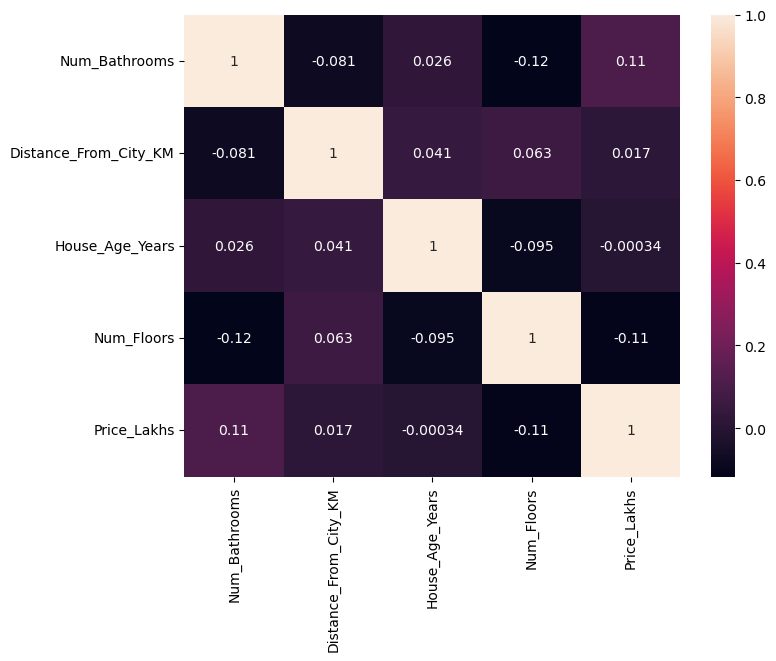

In [25]:
plt.figure(figsize=(8,6))
sns.heatmap(housing_data.select_dtypes(include=['number']).corr(), annot=True)
plt.show()

In [26]:
X = housing_data.drop("Price_Lakhs", axis=1)
y = housing_data["Price_Lakhs"]

In [27]:
from sklearn.model_selection import train_test_split


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:

num_features = X.select_dtypes(include=['int64', 'float64']).columns
cat_features = X.select_dtypes(include=['object']).columns

In [30]:
num_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

In [31]:
model = Pipeline([
    ("preprocessing", preprocessor),
    ("regressor", LinearRegression())
])

In [32]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Num_Bathrooms', 'Distance_From_City_KM', 'House_Age_Years',
       'Num_Floors'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Location', 'Area_Sqft', 'Num_Bedrooms'], dtype='object'))])),
                ('regressor', LinearRegression())])

In [33]:
y_pred = model.predict(X_test)

In [34]:
print("Housing R2 Score:", r2_score(y_test, y_pred))

Housing R2 Score: -121478.70550790855


In [35]:
print(housing_data.dtypes)

Location                  object
Area_Sqft                 object
Num_Bedrooms              object
Num_Bathrooms            float64
Distance_From_City_KM    float64
House_Age_Years          float64
Num_Floors                 int64
Price_Lakhs              float64
dtype: object


In [36]:
cols_to_fix = ["Area_Sqft", "Num_Bedrooms"]

for col in cols_to_fix:
    housing_data[col] = housing_data[col].astype(str).str.replace(",", "")
    housing_data[col] = pd.to_numeric(housing_data[col], errors='coerce')

In [37]:
housing_data = housing_data.fillna(housing_data.median(numeric_only=True))

In [38]:
print(housing_data.dtypes)

Location                  object
Area_Sqft                float64
Num_Bedrooms             float64
Num_Bathrooms            float64
Distance_From_City_KM    float64
House_Age_Years          float64
Num_Floors                 int64
Price_Lakhs              float64
dtype: object


In [39]:
X = housing_data.drop("Price_Lakhs", axis=1)
y = housing_data["Price_Lakhs"]

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [41]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Num_Bathrooms', 'Distance_From_City_KM', 'House_Age_Years',
       'Num_Floors'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Location', 'Area_Sqft', 'Num_Bedrooms'], dtype='object'))])),
                ('regressor', LinearRegression())])

In [42]:
y_pred = model.predict(X_test)

In [44]:
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: -516169.27659091976


In [45]:
print(housing_data["Location"].nunique())
print(housing_data["Location"].unique())

19
['Clifton' 'PECHS' 'North Nazimabad' 'Malir' 'Scheme 33' 'Saddar'
 'Gulshan' 'Bahria Town' 'Korangi' 'Bahriya Town' 'DHA' '  Gulshan  '
 '  Scheme 33  ' '  Malir  ' 'P.E.C.H.S' 'Bahria town' 'Gulshan-e-iqbal'
 '  Saddar  ' '  Korangi  ']


In [46]:
housing_data["Location"] = housing_data["Location"].str.strip().str.lower()

In [47]:
print(housing_data["Location"].value_counts())

Location
clifton            18
saddar             17
gulshan            17
north nazimabad    14
scheme 33          14
korangi            14
pechs              12
malir              10
dha                10
bahria town         6
bahriya town        1
p.e.c.h.s           1
gulshan-e-iqbal     1
Name: count, dtype: int64


In [48]:
X = housing_data.drop(["Price_Lakhs", "Location"], axis=1)
y = housing_data["Price_Lakhs"]

In [ ]:
# Maybe final time model running before submission
X = housing_data.drop("Price_Lakhs", axis=1)
y = housing_data["Price_Lakhs"]